### Import

In [78]:
import os
import gc
import time
import scipy
import pickle 
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt 

from sklearn import metrics
from sklearn.utils import resample
from sklearn.metrics import auc
from sklearn.metrics import log_loss
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

from statsmodels.stats.contingency_tables import mcnemar

### Path

In [79]:
path_cohort_mimiciv  = "../Data/Cohorts/"
path_results_mimiciv = "../Results/"

path_cohort_mimiciii = "../../MIMICIII/Data/Cohorts/"
path_results_mimiciii= "../../MIMICIII/Results/"

### Read Results

In [80]:
tool_1_iii= pd.read_csv(path_results_mimiciii + 'OASIS_Result.csv')
tool_1_iv = pd.read_csv(path_results_mimiciv  + 'OASIS_Result.csv')

tool_2_iii= pd.read_csv(path_results_mimiciii + 'LSTM_FF_Result.csv')
tool_2_iv = pd.read_csv(path_results_mimiciv  + 'LSTM_FF_Result.csv')

In [81]:
tool_1_iii = tool_1_iii[['ICUSTAY_ID', 'probability', 'predicted_label', 'ICU_EXPIRE_FLAG']]
tool_1_iv  = tool_1_iv[['stay_id', 'probability', 'predicted_label', 'icu_expire_flag']]

tool_2_iii = tool_2_iii[['ICUSTAY_ID', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'ICU_EXPIRE_FLAG']]
tool_2_iv  = tool_2_iv[['stay_id', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]

In [82]:
tool_1_iii.columns = ['stay_id', 'tool_1_probability', 'tool_1_label', 'icu_expire_flag']
tool_1_iv.columns  = ['stay_id', 'tool_1_probability', 'tool_1_label', 'icu_expire_flag']

tool_2_iii.columns = ['stay_id', 'tool_2_probability', 'tool_2_label', 'icu_expire_flag']
tool_2_iv.columns  = ['stay_id', 'tool_2_probability', 'tool_2_label', 'icu_expire_flag']

In [83]:
concat_tool_1 = [tool_1_iv, tool_1_iii]
tool_1 = pd.concat(concat_tool_1)

concat_tool_2 = [tool_2_iv, tool_2_iii]
tool_2 = pd.concat(concat_tool_2)

tool_1 = tool_1.sort_values(by='stay_id').reset_index(drop=True)
tool_2 = tool_2.sort_values(by='stay_id').reset_index(drop=True)

In [86]:
print(tool_1.stay_id.nunique())
print(tool_2.stay_id.nunique())

20695
20695


### Merge

In [87]:
results = tool_2.merge(tool_1, on=['stay_id', 'icu_expire_flag'], how='left')
results = results[['stay_id', 'tool_1_probability', 'tool_1_label', 'tool_2_probability', 'tool_2_label', 'icu_expire_flag']]

### Scatter Plot

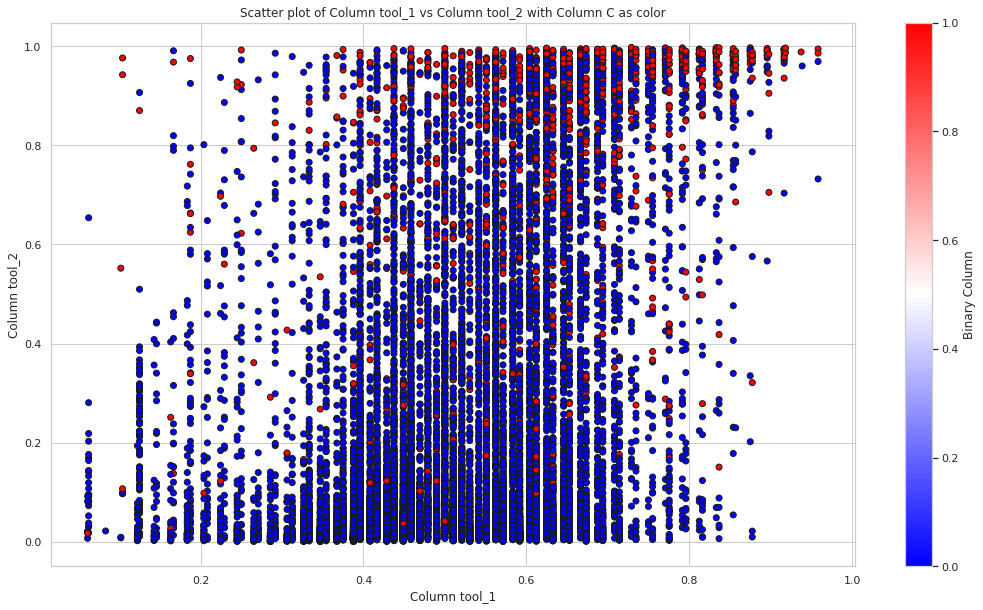

In [88]:
plt.figure(figsize=(18, 10))
scatter = plt.scatter(results['tool_1_probability'], results['tool_2_probability'], c=results['icu_expire_flag'], cmap='bwr', edgecolor='k')

plt.xlabel('Column tool_1')
plt.ylabel('Column tool_2')
plt.title('Scatter plot of Column tool_1 vs Column tool_2 with Column C as color')
plt.colorbar(label='Binary Column')

plt.show()

### ROC

In [89]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [90]:
def get_roc_ci(y_true, y_score):
    
    auc_scores = []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    for j in range(1000):
        try:
            yte_true_b, yte_pred_b = resample(y_true, y_score, replace=True, random_state=j)
            fpr, tpr, _ = metrics.roc_curve(yte_true_b, yte_pred_b)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0
            auc_scores.append(metrics.roc_auc_score(yte_true_b, yte_pred_b))
            
        except Exception as e:
            continue
    
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    
    tprs_upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)
    
    auc = roc_auc_score(y_true, y_score)
    
    return mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc

In [91]:
def plot_roc_with_ci(mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))
    
    plt.plot(mean_fpr, mean_tpr, color='blue', lw=2, label='Mean ROC (AUC = %0.2f)' % np.mean(auc_ci))
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.3)
    
    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='red', label='Chance', alpha=0.8)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

### Precision-Recall

In [92]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [93]:
def get_prc_ci(y_true, y_score):
    
    prc_scores = []
    precisions = []
    recalls = []
    thresholds = np.linspace(0, 1, 100)

    for j in range(1000):
        try:
            yte_true_b, yte_pred_b = resample(y_true, y_score, replace=True, random_state=j)
            precision, recall, _ = metrics.precision_recall_curve(yte_true_b, yte_pred_b)
            prc_score = metrics.auc(recall, precision)
            prc_scores.append(prc_score)
            interp_precision = np.interp(thresholds, recall[::-1], precision[::-1])
            precisions.append(interp_precision)
        except Exception as e:

            continue

    mean_precision = np.mean(precisions, axis=0)
    std_precision = np.std(precisions, axis=0)

    precision_upper = np.minimum(mean_precision + 1.96 * std_precision, 1)
    precision_lower = np.maximum(mean_precision - 1.96 * std_precision, 0)
    
    ap = average_precision_score(y_true, y_score)
    
    return thresholds, mean_precision, precision_lower, precision_upper, ap

In [94]:
def plot_prc_with_ci(thresholds, mean_precision, precision_lower, precision_upper, prc_ci):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))

    plt.plot(thresholds, mean_precision, color='blue', lw=2, label='Mean PRC (AP = %0.2f)' % np.mean(prc_ci))
    plt.fill_between(thresholds, precision_lower, precision_upper, color='grey', alpha=0.3,)
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

### Performance Metrics

In [95]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    Brier = brier_score_loss(true_label, prediction_prob)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))
    print("Brier = " , np.round(Brier,  2))

In [96]:
def Performance_Metrics_CI(true_label, predicted_label, prediction_prob, n_bootstraps=1000, ci=95):
    
    metrics = {
        'ACC': [], 'PRC': [], 'REC': [], 'F1M': [], 'PPV': [],
        'NPV': [], 'SEN': [], 'SPE': [], 'FPR': [], 'FNR': [],
        'FDR': [], 'AUC': [], 'AP': [],  'MCC': [], 'BRR': []}
    
    for i in range(n_bootstraps):
        
        indices = resample(np.arange(len(true_label)), random_state=i)
        true_resampled = np.array(true_label)[indices]
        pred_resampled = np.array(predicted_label)[indices]
        prob_resampled = np.array(prediction_prob)[indices]
        
        TN, FP, FN, TP = confusion_matrix(true_resampled, pred_resampled).ravel()
        metrics['ACC'].append((TP + TN) / (TP + FP + FN + TN))
        metrics['PRC'].append(TP / (TP + FP) if TP + FP > 0 else 0)
        metrics['REC'].append(TP / (TP + FN) if TP + FN > 0 else 0)
        metrics['F1M'].append((2 * metrics['PRC'][-1] * metrics['REC'][-1]) / (metrics['PRC'][-1] + metrics['REC'][-1]) if metrics['PRC'][-1] + metrics['REC'][-1] > 0 else 0)
        metrics['PPV'].append(TP / (TP + FP) if TP + FP > 0 else 0)
        metrics['NPV'].append(TN / (TN + FN) if TN + FN > 0 else 0)
        metrics['SEN'].append(metrics['REC'][-1])
        metrics['SPE'].append(TN / (TN + FP) if TN + FP > 0 else 0)
        metrics['FPR'].append(FP / (FP + TN) if FP + TN > 0 else 0)
        metrics['FNR'].append(FN / (TP + FN) if TP + FN > 0 else 0)
        metrics['FDR'].append(FP / (TP + FP) if TP + FP > 0 else 0)
        metrics['AUC'].append(roc_auc_score(true_resampled, prob_resampled))
        metrics['AP'].append(average_precision_score(true_resampled, prob_resampled))
        metrics['MCC'].append(matthews_corrcoef(true_resampled, pred_resampled))
        metrics['BRR'].append(brier_score_loss(true_resampled, prob_resampled))

    ci_bounds = {}
    for key in metrics:
        lower = np.percentile(metrics[key], (100 - ci) / 2)
        upper = np.percentile(metrics[key], 100 - (100 - ci) / 2)
        mean  = np.mean(metrics[key])
        ci_bounds[key] = (mean, lower, upper)

    for metric, values in ci_bounds.items():
        print(f"{metric} = {values[0]:.3f} ({values[1]:.3f}-{values[2]:.3f})")

In [97]:
Performance_Metrics_CI(results['icu_expire_flag'], results['tool_1_label'], results['tool_1_probability'])

ACC = 0.588 (0.581-0.595)
PRC = 0.117 (0.111-0.124)
REC = 0.776 (0.755-0.798)
F1M = 0.203 (0.193-0.214)
PPV = 0.117 (0.111-0.124)
NPV = 0.972 (0.969-0.975)
SEN = 0.776 (0.755-0.798)
SPE = 0.574 (0.567-0.581)
FPR = 0.426 (0.419-0.433)
FNR = 0.224 (0.202-0.245)
FDR = 0.883 (0.876-0.889)
AUC = 0.752 (0.739-0.766)
AP = 0.220 (0.201-0.240)
MCC = 0.177 (0.165-0.189)
BRR = 0.256 (0.255-0.258)


In [98]:
Performance_Metrics_CI(results['icu_expire_flag'], results['tool_2_label'], results['tool_2_probability'])

ACC = 0.867 (0.862-0.871)
PRC = 0.312 (0.296-0.328)
REC = 0.800 (0.780-0.820)
F1M = 0.449 (0.431-0.466)
PPV = 0.312 (0.296-0.328)
NPV = 0.984 (0.982-0.985)
SEN = 0.800 (0.780-0.820)
SPE = 0.872 (0.867-0.876)
FPR = 0.128 (0.124-0.133)
FNR = 0.200 (0.180-0.220)
FDR = 0.688 (0.672-0.704)
AUC = 0.898 (0.890-0.906)
AP = 0.473 (0.443-0.501)
MCC = 0.446 (0.428-0.462)
BRR = 0.121 (0.118-0.124)


### Plot ROC

In [99]:
lstm_mean_fpr, lstm_mean_tpr, lstm_tprs_lower, lstm_tprs_upper, lstm_auc_ci = get_roc_ci(results['icu_expire_flag'], results['tool_1_probability'])
lstm_ff_mean_fpr, lstm_ff_mean_tpr, lstm_ff_tprs_lower, lstm_ff_tprs_upper, lstm_ff_auc_ci = get_roc_ci(results['icu_expire_flag'], results['tool_2_probability'])

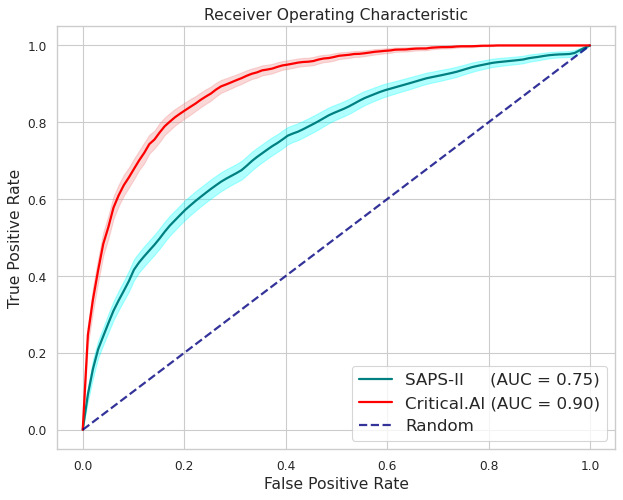

In [100]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=80)

plt.plot(lstm_mean_fpr, lstm_mean_tpr, color='teal', lw=2, label='SAPS-II     (AUC = %0.2f)' % np.mean(lstm_auc_ci))
plt.fill_between(lstm_mean_fpr, lstm_tprs_lower, lstm_tprs_upper, color='aqua', alpha=0.3)

plt.plot(lstm_ff_mean_fpr, lstm_ff_mean_tpr, color='red', lw=2, label='Critical.AI (AUC = %0.2f)' % np.mean(lstm_ff_auc_ci))
plt.fill_between(lstm_ff_mean_fpr, lstm_ff_tprs_lower, lstm_ff_tprs_upper, color='lightcoral', alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='navy', label='Random', alpha=0.8)

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic', fontsize=14)
plt.legend(loc="lower right", fontsize=15)
plt.show()

### Plot Precision-Recall

In [101]:
lstm_thresholds, lstm_mean_precision, lstm_precision_lower, lstm_precision_upper, lstm_prc_ci = get_prc_ci(results['icu_expire_flag'], results['tool_1_probability'])
lstm_ff_thresholds, lstm_ff_mean_precision, lstm_ff_precision_lower, lstm_ff_precision_upper, lstm_ff_prc_ci = get_prc_ci(results['icu_expire_flag'], results['tool_2_probability'])

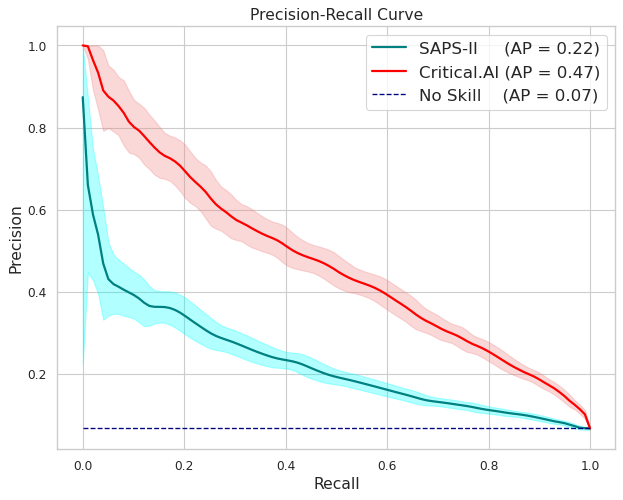

In [102]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=80)

plt.plot(lstm_thresholds, lstm_mean_precision, color='teal', lw=2, label='SAPS-II     (AP = %0.2f)' % np.mean(lstm_prc_ci))
plt.fill_between(lstm_thresholds, lstm_precision_lower, lstm_precision_upper, color='aqua', alpha=0.3,)

plt.plot(lstm_ff_thresholds, lstm_ff_mean_precision, color='red', lw=2, label='Critical.AI (AP = %0.2f)' % np.mean(lstm_ff_prc_ci))
plt.fill_between(lstm_ff_thresholds, lstm_ff_precision_lower, lstm_ff_precision_upper, color='lightcoral', alpha=0.3,)

true_label = np.array(results['icu_expire_flag'])

no_skill = len(true_label[true_label == 1]) / len(true_label)
plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill    (AP = {:.2f})'.format(no_skill))

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curve', fontsize=14)
plt.legend(loc="best", fontsize=15)
plt.show()

### Form Contingency Table for  McNemar's Test

In [103]:
tool_1_labels = results['tool_1_label']
tool_2_labels = results['tool_2_label']
true_labels   = results['icu_expire_flag']

contingency_table = np.zeros((2, 2))

for t1, t2, true in zip(tool_1_labels, tool_2_labels, true_labels):
    if t1 == true and t2 == true:
        contingency_table[0, 0] += 1 
    elif t1 == true and t2 != true:
        contingency_table[0, 1] += 1  
    elif t1 != true and t2 == true:
        contingency_table[1, 0] += 1
    else:
        contingency_table[1, 1] += 1
        
contingency_table

array([[11379.,   789.],
       [ 6559.,  1968.]])

In [104]:
mcnemar_test_result = mcnemar(contingency_table, exact=True)
mcnemar_test_result.pvalue, mcnemar_test_result.statistic

(0.0, 789.0)

### Isolate Disagreement Cases

In [105]:
disagreement_cases = results[results['tool_1_label'] != results['tool_2_label']]

### Analyze Performance in Disagreement Cases

In [106]:
Performance_Metrics_CI(disagreement_cases['icu_expire_flag'], disagreement_cases['tool_1_label'], disagreement_cases['tool_1_probability'])

ACC = 0.107 (0.101-0.114)
PRC = 0.024 (0.021-0.028)
REC = 0.453 (0.400-0.506)
F1M = 0.046 (0.039-0.052)
PPV = 0.024 (0.021-0.028)
NPV = 0.770 (0.740-0.798)
SEN = 0.453 (0.400-0.506)
SPE = 0.090 (0.084-0.097)
FPR = 0.910 (0.903-0.916)
FNR = 0.547 (0.494-0.600)
FDR = 0.976 (0.972-0.979)
AUC = 0.309 (0.273-0.345)
AP = 0.034 (0.030-0.039)
MCC = -0.306 (-0.345--0.270)
BRR = 0.347 (0.345-0.350)


In [107]:
Performance_Metrics_CI(disagreement_cases['icu_expire_flag'], disagreement_cases['tool_2_label'], disagreement_cases['tool_2_probability'])

ACC = 0.893 (0.886-0.899)
PRC = 0.230 (0.202-0.260)
REC = 0.547 (0.494-0.600)
F1M = 0.323 (0.289-0.360)
PPV = 0.230 (0.202-0.260)
NPV = 0.976 (0.972-0.979)
SEN = 0.547 (0.494-0.600)
SPE = 0.910 (0.903-0.916)
FPR = 0.090 (0.084-0.097)
FNR = 0.453 (0.400-0.506)
FDR = 0.770 (0.740-0.798)
AUC = 0.834 (0.814-0.852)
AP = 0.263 (0.216-0.311)
MCC = 0.306 (0.270-0.345)
BRR = 0.120 (0.115-0.125)


In [108]:
lstm_mean_fpr, lstm_mean_tpr, lstm_tprs_lower, lstm_tprs_upper, lstm_auc_ci = get_roc_ci(disagreement_cases['icu_expire_flag'], disagreement_cases['tool_1_probability'])
lstm_ff_mean_fpr, lstm_ff_mean_tpr, lstm_ff_tprs_lower, lstm_ff_tprs_upper, lstm_ff_auc_ci = get_roc_ci(disagreement_cases['icu_expire_flag'], disagreement_cases['tool_2_probability'])

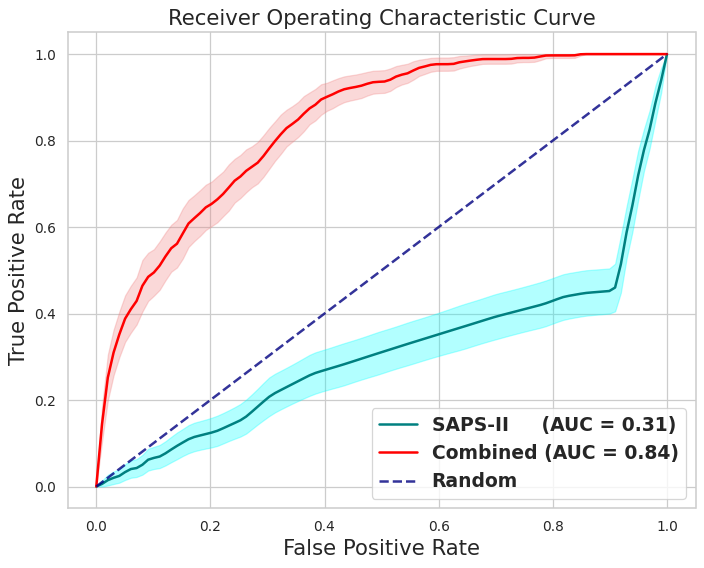

In [109]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(lstm_mean_fpr, lstm_mean_tpr, color='teal', lw=2, label='SAPS-II     (AUC = %0.2f)' % np.mean(lstm_auc_ci))
plt.fill_between(lstm_mean_fpr, lstm_tprs_lower, lstm_tprs_upper, color='aqua', alpha=0.3)

plt.plot(lstm_ff_mean_fpr, lstm_ff_mean_tpr, color='red', lw=2, label='Combined (AUC = %0.2f)' % (np.mean(lstm_ff_auc_ci)))
plt.fill_between(lstm_ff_mean_fpr, lstm_ff_tprs_lower, lstm_ff_tprs_upper, color='lightcoral', alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='navy', label='Random', alpha=0.8)

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=17)
plt.ylabel('True Positive Rate', fontsize=17)
plt.title('Receiver Operating Characteristic Curve', fontsize=17)
# plt.legend(loc="lower right", fontsize=15)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()

In [110]:
lstm_thresholds, lstm_mean_precision, lstm_precision_lower, lstm_precision_upper, lstm_prc_ci = get_prc_ci(disagreement_cases['icu_expire_flag'], disagreement_cases['tool_1_probability'])
lstm_ff_thresholds, lstm_ff_mean_precision, lstm_ff_precision_lower, lstm_ff_precision_upper, lstm_ff_prc_ci = get_prc_ci(disagreement_cases['icu_expire_flag'], disagreement_cases['tool_2_probability'])

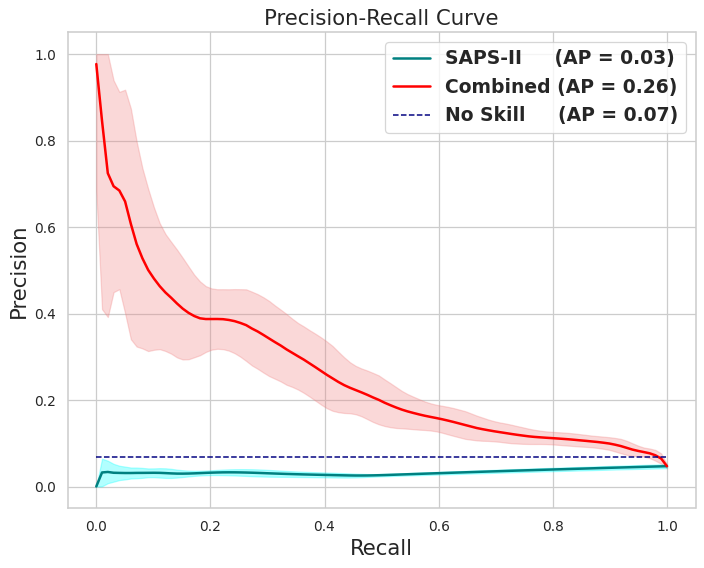

In [111]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(lstm_thresholds, lstm_mean_precision, color='teal', lw=2, label='SAPS-II     (AP = %0.2f)' % np.mean(lstm_prc_ci))
plt.fill_between(lstm_thresholds, lstm_precision_lower, lstm_precision_upper, color='aqua', alpha=0.3,)

plt.plot(lstm_ff_thresholds, lstm_ff_mean_precision, color='red', lw=2, label='Combined (AP = %0.2f)' % np.mean(lstm_ff_prc_ci))
plt.fill_between(lstm_ff_thresholds, lstm_ff_precision_lower, lstm_ff_precision_upper, color='lightcoral', alpha=0.3,)

true_label = np.array(results['icu_expire_flag'])

no_skill = len(true_label[true_label == 1]) / len(true_label)
plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill     (AP = {:.2f})'.format(no_skill))

plt.xlabel('Recall', fontsize=17)
plt.ylabel('Precision', fontsize=17)
plt.title('Precision-Recall Curve', fontsize=17)
# plt.legend(loc="best", fontsize=15)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()

### Net Reclassification Improvement (NRI)

In [112]:
def calculate_nri(tool_1_labels, tool_2_labels, true_labels):
    
    improved = ((tool_1_labels == 0) & (tool_2_labels == 1) & (true_labels == 1)) | \
               ((tool_1_labels == 1) & (tool_2_labels == 0) & (true_labels == 0))
    worsened = ((tool_1_labels == 1) & (tool_2_labels == 0) & (true_labels == 1)) | \
               ((tool_1_labels == 0) & (tool_2_labels == 1) & (true_labels == 0))

    nri = (improved.sum() - worsened.sum()) / len(true_labels)
    
    return nri

In [113]:
true_labels   = results['icu_expire_flag']
tool_1_labels = results['tool_1_label']
tool_2_labels = results['tool_2_label']

nri_value = calculate_nri(tool_1_labels, tool_2_labels, true_labels)

print(nri_value)

0.2788113070790046


In [114]:
true_labels   = disagreement_cases['icu_expire_flag']
tool_1_labels = disagreement_cases['tool_1_label']
tool_2_labels = disagreement_cases['tool_2_label']

nri_value = calculate_nri(tool_1_labels, tool_2_labels, true_labels)

print(nri_value)

0.7852476864452912


### Probability Differences

In [115]:
results['probability_difference'] = abs(results['tool_1_probability'] - results['tool_2_probability'])

In [116]:
tool_2_higher_cases = results[results['tool_2_probability'] > results['tool_1_probability']]
top_10_percent_tool_2_higher = tool_2_higher_cases.nlargest(int(len(results) * 0.1), 'probability_difference')

tool_2_lower_cases = results[results['tool_2_probability'] < results['tool_1_probability']]
top_10_percent_tool_2_lower = tool_2_lower_cases.nlargest(int(len(results) * 0.1), 'probability_difference')

top_10_percent_combined = pd.concat([top_10_percent_tool_2_higher, top_10_percent_tool_2_lower])

In [117]:
mean_fpr_tool_1, mean_tpr_tool_1, tprs_lower_tool_1, tprs_upper_tool_1, auc_ci_tool_1 = get_roc_ci(top_10_percent_combined['icu_expire_flag'], top_10_percent_combined['tool_1_probability'])
mean_fpr_tool_2, mean_tpr_tool_2, tprs_lower_tool_2, tprs_upper_tool_2, auc_ci_tool_2 = get_roc_ci(top_10_percent_combined['icu_expire_flag'], top_10_percent_combined['tool_2_probability'])

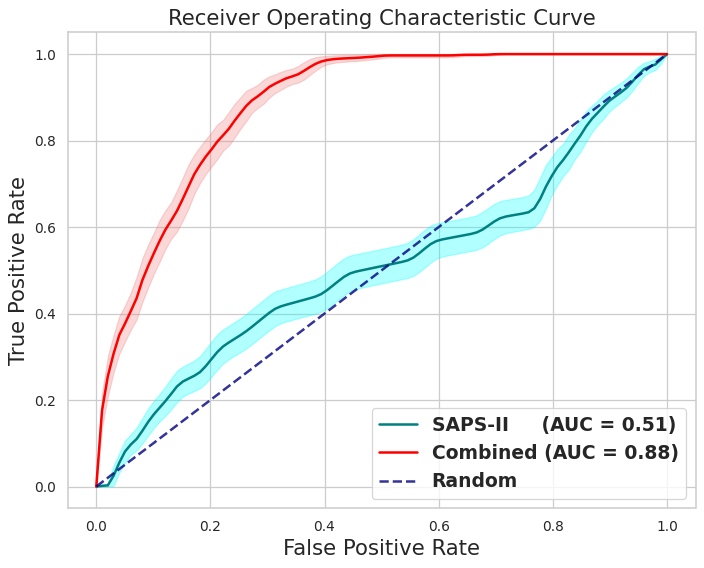

In [118]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(mean_fpr_tool_1, mean_tpr_tool_1, color='teal', lw=2, label='SAPS-II     (AUC = %0.2f)' % np.mean(auc_ci_tool_1))
plt.fill_between(mean_fpr_tool_1, tprs_lower_tool_1, tprs_upper_tool_1, color='aqua', alpha=0.3)

plt.plot(mean_fpr_tool_2, mean_tpr_tool_2, color='red', lw=2, label='Combined (AUC = %0.2f)' % np.mean(auc_ci_tool_2))
plt.fill_between(mean_fpr_tool_2, tprs_lower_tool_2, tprs_upper_tool_2, color='lightcoral', alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='navy', label='Random', alpha=0.8)

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=17)
plt.ylabel('True Positive Rate', fontsize=17)
plt.title('Receiver Operating Characteristic Curve', fontsize=17)
# plt.legend(loc="lower right", fontsize=15)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()

In [119]:
lstm_thresholds, lstm_mean_precision, lstm_precision_lower, lstm_precision_upper, lstm_prc_ci = get_prc_ci(top_10_percent_combined['icu_expire_flag'], top_10_percent_combined['tool_1_probability'])
lstm_ff_thresholds, lstm_ff_mean_precision, lstm_ff_precision_lower, lstm_ff_precision_upper, lstm_ff_prc_ci = get_prc_ci(top_10_percent_combined['icu_expire_flag'], top_10_percent_combined['tool_2_probability'])

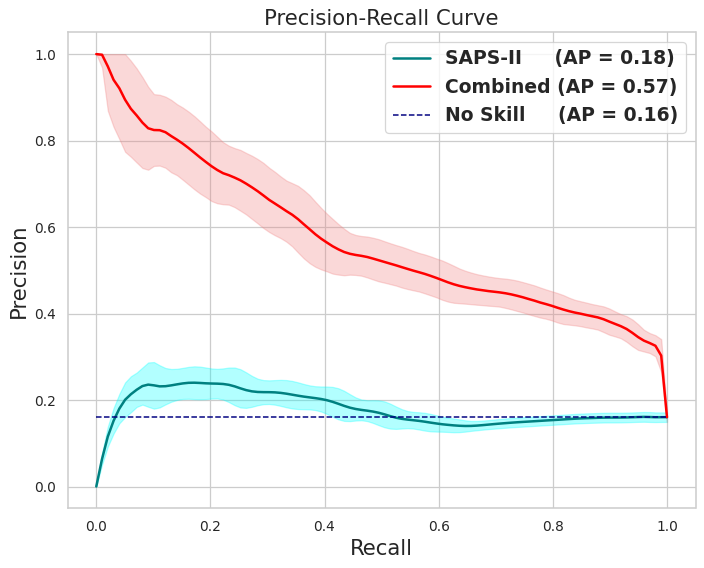

In [120]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(lstm_thresholds, lstm_mean_precision, color='teal', lw=2, label='SAPS-II     (AP = %0.2f)' % np.mean(lstm_prc_ci))
plt.fill_between(lstm_thresholds, lstm_precision_lower, lstm_precision_upper, color='aqua', alpha=0.3,)

plt.plot(lstm_ff_thresholds, lstm_ff_mean_precision, color='red', lw=2, label='Combined (AP = %0.2f)' % np.mean(lstm_ff_prc_ci))
plt.fill_between(lstm_ff_thresholds, lstm_ff_precision_lower, lstm_ff_precision_upper, color='lightcoral', alpha=0.3,)

true_label = np.array(top_10_percent_combined['icu_expire_flag'])

no_skill = len(true_label[true_label == 1]) / len(true_label)
plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill     (AP = {:.2f})'.format(no_skill))

plt.xlabel('Recall', fontsize=17)
plt.ylabel('Precision', fontsize=17)
plt.title('Precision-Recall Curve', fontsize=17)
# plt.legend(loc="best", fontsize=15)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()

### Identify Maximum Disagreement Cases

In [121]:
top_percent_threshold = results['probability_difference'].quantile(0.8)
high_disagreement_cases  = results[results['probability_difference'] > top_percent_threshold]

In [122]:
mean_fpr_tool_1, mean_tpr_tool_1, tprs_lower_tool_1, tprs_upper_tool_1, auc_ci_tool_1 = get_roc_ci(high_disagreement_cases['icu_expire_flag'], high_disagreement_cases['tool_1_probability'])
mean_fpr_tool_2, mean_tpr_tool_2, tprs_lower_tool_2, tprs_upper_tool_2, auc_ci_tool_2 = get_roc_ci(high_disagreement_cases['icu_expire_flag'], high_disagreement_cases['tool_2_probability'])

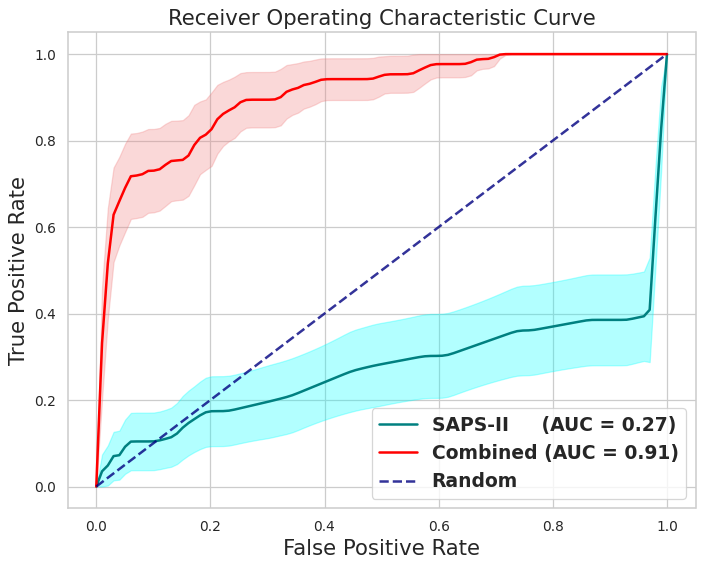

In [138]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(mean_fpr_tool_1, mean_tpr_tool_1, color='teal', lw=2, label='SAPS-II     (AUC = %0.2f)' % np.mean(auc_ci_tool_1))
plt.fill_between(mean_fpr_tool_1, tprs_lower_tool_1, tprs_upper_tool_1, color='aqua', alpha=0.3)

plt.plot(mean_fpr_tool_2, mean_tpr_tool_2, color='red', lw=2, label='Combined (AUC = %0.2f)' % np.mean(auc_ci_tool_2))
plt.fill_between(mean_fpr_tool_2, tprs_lower_tool_2, tprs_upper_tool_2, color='lightcoral', alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='navy', label='Random', alpha=0.8)

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=17)
plt.ylabel('True Positive Rate', fontsize=17)
plt.title('Receiver Operating Characteristic Curve', fontsize=17)
# plt.legend(loc="lower right", fontsize=15)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()

In [124]:
lstm_thresholds, lstm_mean_precision, lstm_precision_lower, lstm_precision_upper, lstm_prc_ci = get_prc_ci(high_disagreement_cases['icu_expire_flag'], high_disagreement_cases['tool_1_probability'])
lstm_ff_thresholds, lstm_ff_mean_precision, lstm_ff_precision_lower, lstm_ff_precision_upper, lstm_ff_prc_ci = get_prc_ci(high_disagreement_cases['icu_expire_flag'], high_disagreement_cases['tool_2_probability'])

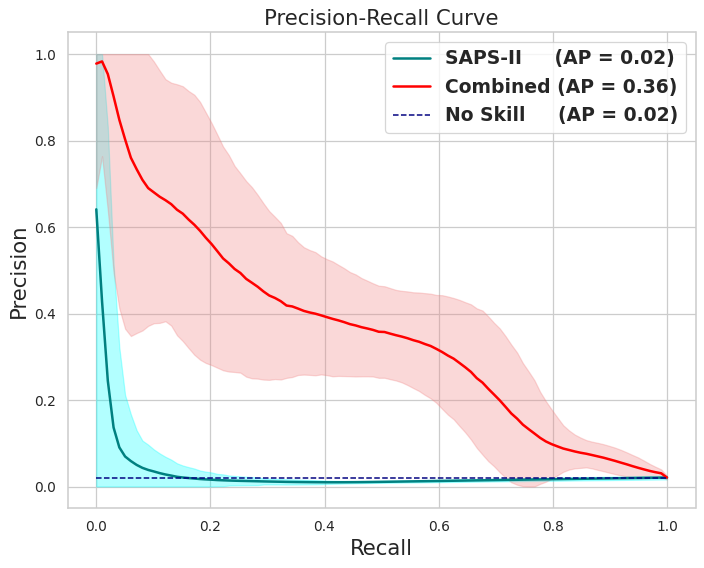

In [140]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(lstm_thresholds, lstm_mean_precision, color='teal', lw=2, label='SAPS-II     (AP = %0.2f)' % np.mean(lstm_prc_ci))
plt.fill_between(lstm_thresholds, lstm_precision_lower, lstm_precision_upper, color='aqua', alpha=0.3,)

plt.plot(lstm_ff_thresholds, lstm_ff_mean_precision, color='red', lw=2, label='Combined (AP = %0.2f)' % np.mean(lstm_ff_prc_ci))
plt.fill_between(lstm_ff_thresholds, lstm_ff_precision_lower, lstm_ff_precision_upper, color='lightcoral', alpha=0.3,)

true_label = np.array(high_disagreement_cases['icu_expire_flag'])

no_skill = len(true_label[true_label == 1]) / len(true_label)
plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill     (AP = {:.2f})'.format(no_skill))

plt.xlabel('Recall', fontsize=17)
plt.ylabel('Precision', fontsize=17)
plt.title('Precision-Recall Curve', fontsize=17)
# plt.legend(loc="best", fontsize=15)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()

### Categorize Disagreement Cases
Categorize based on whether Tool-1 or Tool-2 predicts a higher probability

<ipython-input>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_disagreement_cases['tool_1_higher'] = high_disagreement_cases['tool_1_probability'] > high_disagreement_cases['tool_2_probability']


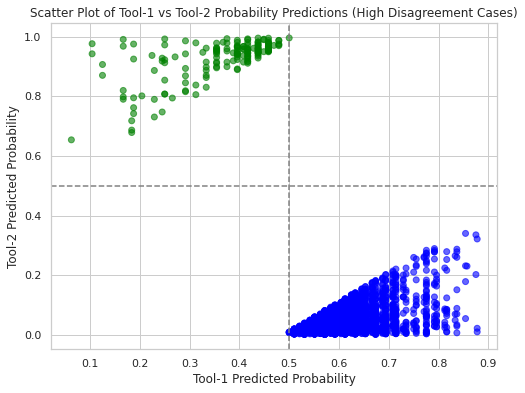

In [126]:
high_disagreement_cases['tool_1_higher'] = high_disagreement_cases['tool_1_probability'] > high_disagreement_cases['tool_2_probability']

plt.figure(figsize=(8, 6))

plt.scatter(high_disagreement_cases['tool_1_probability'], high_disagreement_cases['tool_2_probability'], 
            c=high_disagreement_cases['tool_1_higher'].map({True: 'blue', False: 'green'}), alpha=0.6)

plt.title('Scatter Plot of Tool-1 vs Tool-2 Probability Predictions (High Disagreement Cases)')
plt.xlabel('Tool-1 Predicted Probability')
plt.ylabel('Tool-2 Predicted Probability')
plt.axhline(0.5, color='gray', linestyle='--')
plt.axvline(0.5, color='gray', linestyle='--')
plt.grid(True)
plt.show()

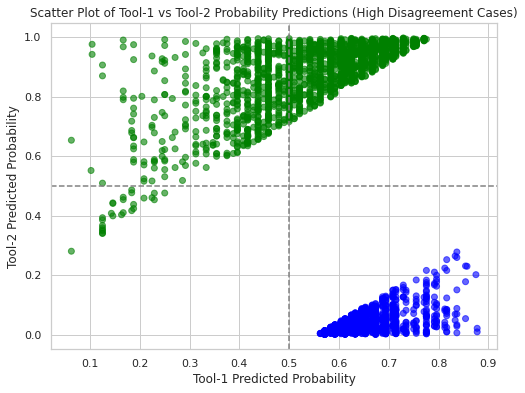

In [127]:
top_10_percent_combined['tool_1_higher'] = top_10_percent_combined['tool_1_probability'] > top_10_percent_combined['tool_2_probability']

plt.figure(figsize=(8, 6))

plt.scatter(top_10_percent_combined['tool_1_probability'], top_10_percent_combined['tool_2_probability'], 
            c=top_10_percent_combined['tool_1_higher'].map({True: 'blue', False: 'green'}), alpha=0.6)

plt.title('Scatter Plot of Tool-1 vs Tool-2 Probability Predictions (High Disagreement Cases)')
plt.xlabel('Tool-1 Predicted Probability')
plt.ylabel('Tool-2 Predicted Probability')
plt.axhline(0.5, color='gray', linestyle='--')
plt.axvline(0.5, color='gray', linestyle='--')
plt.grid(True)
plt.show()

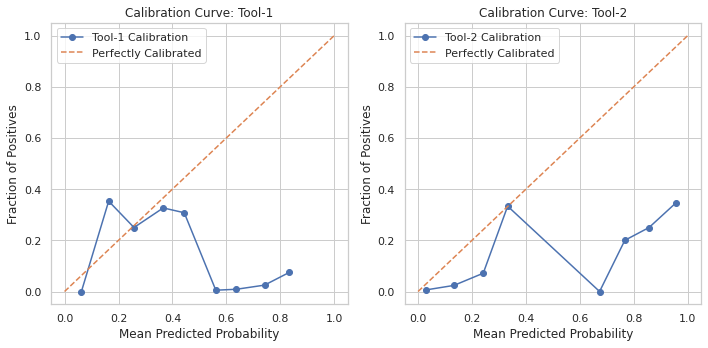

In [128]:
def plot_calibration_curve(probs, true_labels, tool_name):
    
    fraction_of_positives, mean_predicted_value = calibration_curve(true_labels, probs, n_bins=10)
    
    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f'{tool_name} Calibration')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
    plt.title(f'Calibration Curve: {tool_name}')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.legend()
    plt.grid(True)
    
plt.figure(figsize=(10, 5))

# Tool-1
plt.subplot(1, 2, 1)
plot_calibration_curve(high_disagreement_cases['tool_1_probability'], high_disagreement_cases['icu_expire_flag'], 'Tool-1')

# Tool-2
plt.subplot(1, 2, 2)
plot_calibration_curve(high_disagreement_cases['tool_2_probability'], high_disagreement_cases['icu_expire_flag'], 'Tool-2')

plt.tight_layout()
plt.show()

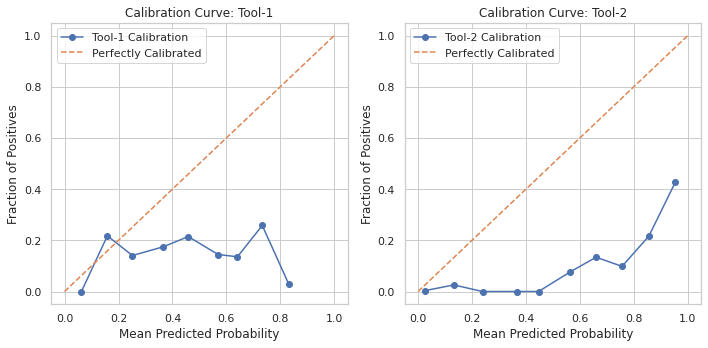

In [129]:
def plot_calibration_curve(probs, true_labels, tool_name):
    
    fraction_of_positives, mean_predicted_value = calibration_curve(true_labels, probs, n_bins=10)
    
    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f'{tool_name} Calibration')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
    plt.title(f'Calibration Curve: {tool_name}')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.legend()
    plt.grid(True)
    
plt.figure(figsize=(10, 5))

# Tool-1
plt.subplot(1, 2, 1)
plot_calibration_curve(top_10_percent_combined['tool_1_probability'], top_10_percent_combined['icu_expire_flag'], 'Tool-1')

# Tool-2
plt.subplot(1, 2, 2)
plot_calibration_curve(top_10_percent_combined['tool_2_probability'], top_10_percent_combined['icu_expire_flag'], 'Tool-2')

plt.tight_layout()
plt.show()

In [130]:
brier_tool_1 = brier_score_loss(high_disagreement_cases['icu_expire_flag'], high_disagreement_cases['tool_1_probability'])
brier_tool_2 = brier_score_loss(high_disagreement_cases['icu_expire_flag'], high_disagreement_cases['tool_2_probability'])

log_loss_tool_1 = log_loss(high_disagreement_cases['icu_expire_flag'], high_disagreement_cases['tool_1_probability'])
log_loss_tool_2 = log_loss(high_disagreement_cases['icu_expire_flag'], high_disagreement_cases['tool_2_probability'])

brier_logloss_results = pd.DataFrame({'Metric': ['Brier Score', 'Log-Loss'],
                                      'Tool-1': [brier_tool_1, log_loss_tool_1],
                                      'Tool-2': [brier_tool_2, log_loss_tool_2]})

brier_logloss_results

,Metric,Tool-1,Tool-2
0,Brier Score,0.364124,0.032684
1,Log-Loss,0.931714,0.136977


In [131]:
brier_tool_1 = brier_score_loss(top_10_percent_combined['icu_expire_flag'], top_10_percent_combined['tool_1_probability'])
brier_tool_2 = brier_score_loss(top_10_percent_combined['icu_expire_flag'], top_10_percent_combined['tool_2_probability'])

log_loss_tool_1 = log_loss(top_10_percent_combined['icu_expire_flag'], top_10_percent_combined['tool_1_probability'])
log_loss_tool_2 = log_loss(top_10_percent_combined['icu_expire_flag'], top_10_percent_combined['tool_2_probability'])

brier_logloss_results = pd.DataFrame({'Metric': ['Brier Score', 'Log-Loss'],
                                      'Tool-1': [brier_tool_1, log_loss_tool_1],
                                      'Tool-2': [brier_tool_2, log_loss_tool_2]})

brier_logloss_results

,Metric,Tool-1,Tool-2
0,Brier Score,0.333839,0.261669
1,Log-Loss,0.869882,0.826844


In [132]:
def bland_altman_plot(probs_1, probs_2):
    
    mean_probs = (probs_1 + probs_2) / 2
    diff_probs = probs_1 - probs_2  
    mean_diff = np.mean(diff_probs)
    std_diff = np.std(diff_probs)
    
    plt.scatter(mean_probs, diff_probs, alpha=0.6)
    plt.axhline(mean_diff, color='gray', linestyle='--', label=f'Mean Difference: {mean_diff:.2f}')
    plt.axhline(mean_diff + 1.96 * std_diff, color='red', linestyle='--', label='Upper 95% Limit')
    plt.axhline(mean_diff - 1.96 * std_diff, color='blue', linestyle='--', label='Lower 95% Limit')
    plt.title('Bland-Altman Plot of Probability Differences (Tool-1 vs Tool-2)')
    plt.xlabel('Mean of Tool-1 and Tool-2 Predicted Probabilities')
    plt.ylabel('Difference (Tool-1 - Tool-2)')
    plt.legend()
    plt.grid(True)



def plot_roc_curve(probs, true_labels, tool_name):
    fpr, tpr, _ = roc_curve(true_labels, probs)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{tool_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
    plt.title(f'ROC Curve: {tool_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.grid(True)
    plt.legend()

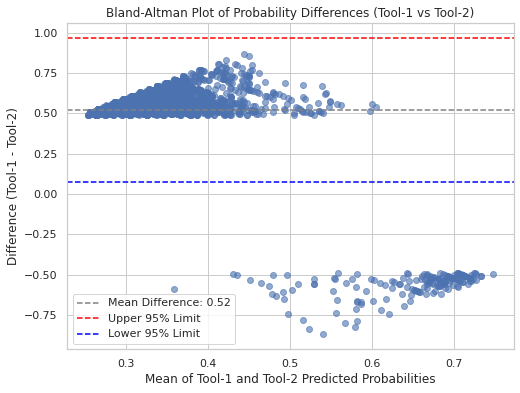

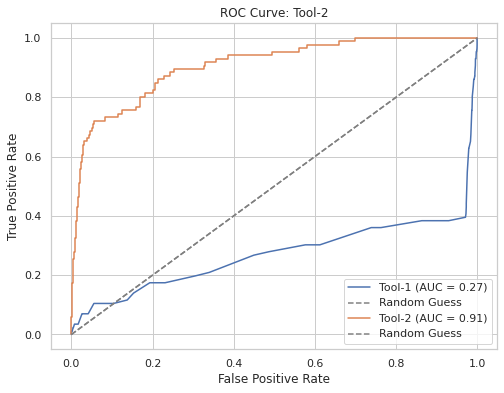

In [133]:
plt.figure(figsize=(8, 6))
bland_altman_plot(high_disagreement_cases['tool_1_probability'], high_disagreement_cases['tool_2_probability'])
plt.show()

plt.figure(figsize=(8, 6))

plot_roc_curve(high_disagreement_cases['tool_1_probability'], high_disagreement_cases['icu_expire_flag'], 'Tool-1')

plot_roc_curve(high_disagreement_cases['tool_2_probability'], high_disagreement_cases['icu_expire_flag'], 'Tool-2')

plt.legend()
plt.grid(True)
plt.show()

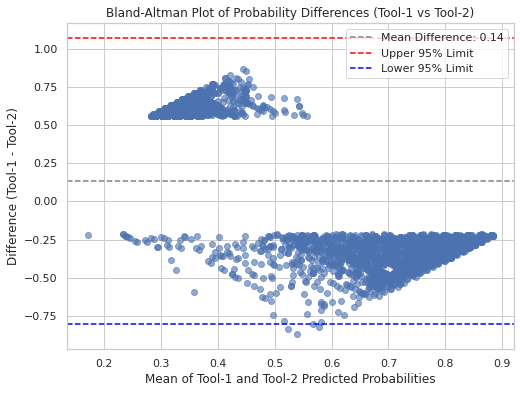

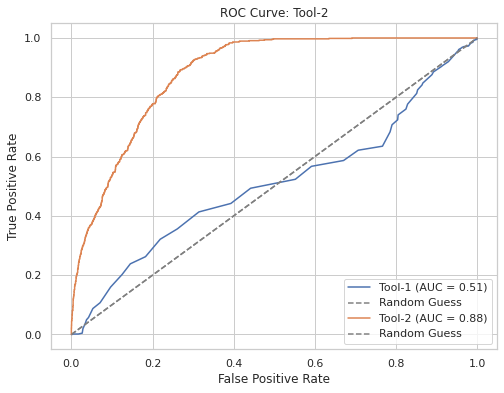

In [134]:
plt.figure(figsize=(8, 6))
bland_altman_plot(top_10_percent_combined['tool_1_probability'], top_10_percent_combined['tool_2_probability'])
plt.show()

plt.figure(figsize=(8, 6))

plot_roc_curve(top_10_percent_combined['tool_1_probability'], top_10_percent_combined['icu_expire_flag'], 'Tool-1')

plot_roc_curve(top_10_percent_combined['tool_2_probability'], top_10_percent_combined['icu_expire_flag'], 'Tool-2')

plt.legend()
plt.grid(True)
plt.show()